# Bank Marketing Campaign & Customer Response Analysis

## Business Objective
Analyze bank marketing campaign data to understand which customer groups respond better to term-deposit campaigns and build a simple Logistic Regression model to estimate response probability.

The project focuses on:
- campaign response analysis,
- customer segmentation,
- hypothesis testing,
- Logistic Regression,
- and converting predicted probabilities into practical targeting segments.

**Dataset:** UCI Bank Marketing (`bank-full.csv`, 45,211 records).

## 1. Import Libraries
Only the libraries required for the analysis and model are imported.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

## 2. Load and Understand the Data
The original file uses a semicolon (`;`) separator.

In [5]:
bank_data = pd.read_csv("bank_marketing_cleaned.csv", sep=",")
print("Rows and columns:", bank_data.shape)
print("Missing values:", bank_data.isnull().sum().sum())
print("Duplicate rows:", bank_data.duplicated().sum())
bank_data.head()

Rows and columns: (45211, 19)
Missing values: 0
Duplicate rows: 0


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,subscribed,age_group
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0,51-60
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0,41-50
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0,31-40
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0,41-50
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0,31-40


### Important Data Notes
- `y` is the original target: `yes` = subscribed, `no` = did not subscribe.
- `poutcome` is the outcome of the previous marketing campaign.
- `campaign` is the number of contacts made during the current campaign.
- `previous` is the number of contacts made before the current campaign.
- `pdays = -1` means the customer had not been contacted in a previous campaign.
- `unknown` values in job, education, contact and previous campaign outcome are retained as valid categories rather than guessed or imputed.

## 3. Create Simple Analysis Variables
A binary target makes response-rate calculations easy: the average of a 0/1 variable is the response proportion.

In [6]:
# Unique ID for SQL / Power BI
bank_data.insert(0, "customer_id", range(1, len(bank_data) + 1))

# 1 = subscribed, 0 = did not subscribe
bank_data["subscribed"] = bank_data["y"].map({"yes": 1, "no": 0})

# Age groups for business analysis
bank_data["age_group"] = pd.cut(
    bank_data["age"],
    bins=[0, 30, 40, 50, 60, float("inf")],
    labels=["<=30", "31-40", "41-50", "51-60", "60+"]
)

# Contact-frequency groups for SQL / Power BI
bank_data["contact_band"] = pd.cut(
    bank_data["campaign"],
    bins=[0, 1, 3, 5, float("inf")],
    labels=["1 Contact", "2-3 Contacts", "4-5 Contacts", "6+ Contacts"]
)

## 4. Overall Campaign KPIs

In [7]:
total_customers = len(bank_data)
total_subscribers = bank_data["subscribed"].sum()
overall_response_rate = bank_data["subscribed"].mean() * 100
average_campaign_contacts = bank_data["campaign"].mean()

print("Total customers:", total_customers)
print("Total subscribers:", total_subscribers)
print("Overall response rate:", round(overall_response_rate, 2), "%")
print("Average campaign contacts:", round(average_campaign_contacts, 2))

Total customers: 45211
Total subscribers: 5289
Overall response rate: 11.7 %
Average campaign contacts: 2.76


## 5. Focused Exploratory Analysis
Only the variables most useful for campaign targeting are summarized.

In [11]:
age_group_summary = (
    bank_data.groupby("age_group", observed=False)
    .agg(customers=("subscribed", "size"), subscribers=("subscribed", "sum"), response_rate=("subscribed", "mean"))
    .reset_index()
)
age_group_summary["response_rate"] *= 100
age_group_summary

,age_group,customers,subscribers,response_rate
0,<=30,7030,1145,16.287340
1,31-40,17687,1812,10.244813
2,41-50,11239,1019,9.066643
3,51-60,8067,811,10.053304
4,60+,1188,502,42.255892


In [13]:
job_summary = (
    bank_data.groupby("job")
    .agg(customers=("subscribed", "size"), subscribers=("subscribed", "sum"), response_rate=("subscribed", "mean"))
    .reset_index()
)
job_summary["response_rate"] *= 100
job_summary.sort_values("response_rate", ascending=False)

,job,customers,subscribers,response_rate
8,student,938,269,28.678038
5,retired,2264,516,22.791519
10,unemployed,1303,202,15.502686
4,management,9458,1301,13.755551
0,admin.,5171,631,12.202669
6,self-employed,1579,187,11.842939
11,unknown,288,34,11.805556
9,technician,7597,840,11.056996
7,services,4154,369,8.883004
3,housemaid,1240,109,8.790323


In [14]:
previous_campaign_summary = (
    bank_data.groupby("poutcome")
    .agg(customers=("subscribed", "size"), subscribers=("subscribed", "sum"), response_rate=("subscribed", "mean"))
    .reset_index()
)
previous_campaign_summary["response_rate"] *= 100
previous_campaign_summary.sort_values("response_rate", ascending=False)

,poutcome,customers,subscribers,response_rate
2,success,1511,978,64.725347
1,other,1840,307,16.684783
0,failure,4901,618,12.609671
3,unknown,36959,3386,9.161503


In [15]:
# Two additional business comparisons
housing_response = bank_data.groupby("housing")["subscribed"].mean().mul(100)
personal_loan_response = bank_data.groupby("loan")["subscribed"].mean().mul(100)
print("Response rate by housing-loan status (%):")
print(housing_response.round(2))
print("Response rate by personal-loan status (%):")
print(personal_loan_response.round(2))

Response rate by housing-loan status (%):
housing
no     16.7
yes     7.7
Name: subscribed, dtype: float64
Response rate by personal-loan status (%):
loan
no     12.66
yes     6.68
Name: subscribed, dtype: float64


### Simple Visuals
These charts are intentionally basic; detailed presentation is handled in Power BI.

In [ ]:
previous_campaign_summary.sort_values("response_rate", ascending=False).plot(
    x="poutcome", y="response_rate", kind="bar", legend=False,
    title="Response Rate by Previous Campaign Outcome"
)
plt.ylabel("Response Rate (%)")
plt.xlabel("Previous Campaign Outcome")
plt.tight_layout()
plt.show()

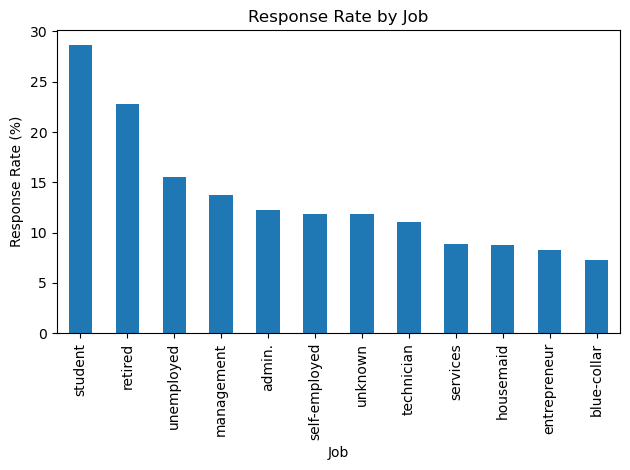

In [16]:
job_summary.sort_values("response_rate", ascending=False).plot(
    x="job", y="response_rate", kind="bar", legend=False,
    title="Response Rate by Job"
)
plt.ylabel("Response Rate (%)")
plt.xlabel("Job")
plt.tight_layout()
plt.show()

## 6. Hypothesis Testing
Two tests are enough to demonstrate the statistical logic clearly.

### Test 1 — Previous campaign outcome vs subscription
- **H0:** Previous campaign outcome and subscription are independent.
- **H1:** They are associated.
- A Chi-square test is used because both variables are categorical.

In [17]:
previous_campaign_table = pd.crosstab(bank_data["poutcome"], bank_data["subscribed"])
chi_square_stat, previous_campaign_p_value, _, _ = chi2_contingency(previous_campaign_table)
print("Chi-square statistic:", round(chi_square_stat, 2))
print("p-value:", previous_campaign_p_value)
if previous_campaign_p_value < 0.05:
    print("Conclusion: Reject H0. Previous campaign outcome is associated with subscription.")
else:
    print("Conclusion: Fail to reject H0. No significant association was found.")

Chi-square statistic: 4391.51
p-value: 0.0
Conclusion: Reject H0. Previous campaign outcome is associated with subscription.


### Test 2 — Age of subscribers vs non-subscribers
- **H0:** Mean age is the same for subscribers and non-subscribers.
- **H1:** Mean age is different.
- Welch's t-test is used because it does not require equal group variances.

In [18]:
subscriber_ages = bank_data.loc[bank_data["subscribed"] == 1, "age"]
non_subscriber_ages = bank_data.loc[bank_data["subscribed"] == 0, "age"]
age_t_stat, age_p_value = ttest_ind(subscriber_ages, non_subscriber_ages, equal_var=False)
print("Average age - subscribers:", round(subscriber_ages.mean(), 2))
print("Average age - non-subscribers:", round(non_subscriber_ages.mean(), 2))
print("p-value:", age_p_value)
if age_p_value < 0.05:
    print("Conclusion: Reject H0. Mean age differs significantly between the groups.")
else:
    print("Conclusion: Fail to reject H0. No significant mean-age difference was found.")

Average age - subscribers: 41.67
Average age - non-subscribers: 40.84
p-value: 1.5971046743760372e-05
Conclusion: Reject H0. Mean age differs significantly between the groups.


## 7. Logistic Regression Model
The model estimates subscription probability.

`duration` is deliberately excluded because call duration is only known during/after the call and would create leakage for targeting.

A compact preprocessing pipeline is retained because numeric variables need scaling and categorical variables need one-hot encoding. Keeping both steps together also ensures train, test and scoring data are prepared consistently.

In [19]:
model_columns = [
    "age", "job", "marital", "education", "balance",
    "housing", "loan", "contact", "campaign",
    "pdays", "previous", "poutcome"
]
number_columns = ["age", "balance", "campaign", "pdays", "previous"]
category_columns = ["job", "marital", "education", "housing", "loan", "contact", "poutcome"]
customer_features = bank_data[model_columns]
subscription_target = bank_data["subscribed"]

In [20]:
train_features, test_features, train_target, test_target = train_test_split(
    customer_features,
    subscription_target,
    test_size=0.20,
    random_state=42,
    stratify=subscription_target
)

In [21]:
# Prepare numeric and categorical columns in one clear step.
data_preparation = ColumnTransformer([
    ("numbers", StandardScaler(), number_columns),
    ("categories", OneHotEncoder(handle_unknown="ignore"), category_columns)
])

response_model = Pipeline([
    ("prepare_data", data_preparation),
    ("logistic_regression", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

response_model.fit(train_features, train_target)

,steps,"[('prepare_data', ...), ('logistic_regression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numbers', ...), ('categories', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


`class_weight="balanced"` gives more importance to the smaller subscriber class so the model does not simply favor the much larger non-subscriber class.

In [22]:
predicted_response = response_model.predict(test_features)
predicted_probability = response_model.predict_proba(test_features)[:, 1]

model_accuracy = accuracy_score(test_target, predicted_response)
model_precision = precision_score(test_target, predicted_response)
model_recall = recall_score(test_target, predicted_response)
model_f1 = f1_score(test_target, predicted_response)
model_roc_auc = roc_auc_score(test_target, predicted_probability)

print("Accuracy:", round(model_accuracy, 3))
print("Precision:", round(model_precision, 3))
print("Recall:", round(model_recall, 3))
print("F1 score:", round(model_f1, 3))
print("ROC-AUC:", round(model_roc_auc, 3))
print("Confusion matrix:")
print(confusion_matrix(test_target, predicted_response))

Accuracy: 0.69
Precision: 0.227
Recall: 0.682
F1 score: 0.34
ROC-AUC: 0.753
Confusion matrix:
[[5520 2465]
 [ 336  722]]


### How to interpret the model
- **Recall:** proportion of actual responders the model identifies.
- **Precision:** proportion of predicted responders who actually respond.
- **ROC-AUC:** how well the model ranks likely responders above non-responders across thresholds.
- Because the response class is relatively small, accuracy alone is not the best metric.

## 8. Create the Final Master Dataset for SQL / Power BI
Model performance is evaluated only on the held-out test set above.

After evaluation, the model is refit on all records and used to assign each customer an illustrative response probability for dashboarding and prioritization. These full-data probabilities are **not** used to report model accuracy.

In [23]:
# Refit on all available records after test-set evaluation.
response_model.fit(customer_features, subscription_target)
all_customer_probabilities = response_model.predict_proba(customer_features)[:, 1]

master_data = bank_data.copy()
master_data["predicted_response_probability"] = all_customer_probabilities

# Four equally sized targeting groups based on predicted probability.
master_data["targeting_segment"] = pd.qcut(
    master_data["predicted_response_probability"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

In [24]:
targeting_summary = (
    master_data.groupby("targeting_segment", observed=False)
    .agg(
        customers=("customer_id", "count"),
        actual_subscribers=("subscribed", "sum"),
        actual_response_rate=("subscribed", "mean"),
        average_predicted_probability=("predicted_response_probability", "mean")
    )
    .reset_index()
)
targeting_summary["actual_response_rate"] *= 100
targeting_summary["average_predicted_probability"] *= 100
targeting_summary.round(2)

,targeting_segment,customers,actual_subscribers,actual_response_rate,average_predicted_probability
0,Low,11303,426,3.77,20.18
1,Medium,11303,724,6.41,35.92
2,High,11302,1146,10.14,48.46
3,Very High,11303,2993,26.48,66.95


## 9. Export Final Files
Use `bank_marketing_master.csv` as the single Power BI file. It contains all original variables plus:
- `customer_id`
- `subscribed`
- `age_group`
- `contact_band`
- `predicted_response_probability`
- `targeting_segment`

In [25]:
master_data.to_csv("bank_marketing_master.csv", index=False)
targeting_summary.to_csv("bank_marketing_targeting_summary.csv", index=False)
print("Saved: bank_marketing_master.csv")
print("Saved: bank_marketing_targeting_summary.csv")
print("Master dataset shape:", master_data.shape)

Saved: bank_marketing_master.csv
Saved: bank_marketing_targeting_summary.csv
Master dataset shape: (45211, 23)


## 10. Key Business Findings to Report
From the original run of this dataset:
- Overall response rate is about **11.70%**.
- A **successful previous campaign outcome** is associated with a much higher observed response rate.
- **Students and retired customers** show relatively high observed response rates by occupation.
- Customers without housing or personal loans show higher observed response rates in this dataset.
- Logistic Regression achieved approximately **0.753 ROC-AUC** and **68.2% recall** on the held-out test sample in the original run.

These are associations and predictive patterns, not causal claims.